A script for aligning brainreg output to probe survey and channel map

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from matplotlib.colors import LogNorm, Normalize
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import colorsys
import matplotlib

from kilosort_SGLX_funcs.SGLXMetaToCoords import MetaToCoords

In [4]:
"""Paths for JAL6"""

# brainreg output
brainreg = Path(r"Z:\Jasmine_Laurence\Histology\MouseID_006\brainreg\segmentation\atlas_space\tracks")

# probe survey
srvy = Path(r"Z:\Jasmine_Laurence\JAL006\SvyPrb_2024-03-21T11.07.43_g0")

# channel map
meta = Path(r"Z:\Jasmine_Laurence\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\barrier_flip6_g0\barrier_flip6_g0_imec0\barrier_flip6_g0_t0.imec0.ap.meta")

In [5]:
"""Colormap generation functions"""
# Get tab20b colors

tab20b_cmap = matplotlib.colormaps.get_cmap('tab20b')
tab20b_colors = [tab20b_cmap(i) for i in range(20)]

# Create a function to reorder colors for maximum contrast between adjacent regions
def reorder_colors_for_contrast(colors, n_colors_needed):
    # If we need more colors than tab20b provides (20), we'll generate additional ones
    if n_colors_needed > len(colors):
        # Generate additional colors with HSV for better control
        additional_colors = generate_distinct_colors(n_colors_needed - len(colors))
        colors = list(colors) + additional_colors
    
    # Reordering strategy: take colors from different parts of the palette
    # to maximize distinction between adjacent values
    reordered = []
    positions = []
    
    # First, use every 4th color
    for i in range(0, n_colors_needed, 4):
        if i < n_colors_needed:
            positions.append(i)
    
    # Then fill in with every 4th+2 color
    for i in range(2, n_colors_needed, 4):
        if i < n_colors_needed and i not in positions:
            positions.append(i)
    
    # Then fill in with every 4th+1 color
    for i in range(1, n_colors_needed, 4):
        if i < n_colors_needed and i not in positions:
            positions.append(i)
    
    # Then fill in with every 4th+3 color
    for i in range(3, n_colors_needed, 4):
        if i < n_colors_needed and i not in positions:
            positions.append(i)
    
    # Create final reordered list
    positions = sorted(positions)
    for i in range(n_colors_needed):
        reordered.append(colors[positions.index(i)])
    
    return reordered

# Generate additional distinct colors if needed
def generate_distinct_colors(n):
    HSV_tuples = [(x/n, 0.8, 0.9) for x in range(n)]
    RGB_tuples = [colorsys.hsv_to_rgb(*x) for x in HSV_tuples]
    return RGB_tuples

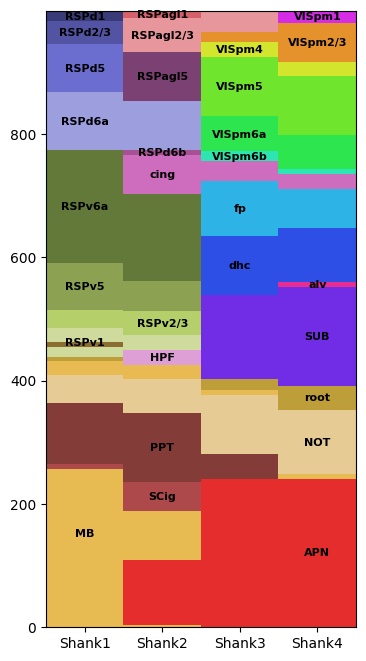

In [6]:
"""Load in the brainreg track data"""
for i in range(4):
    track_path = Path(brainreg, f'track_{i}.csv')
    # Load in coordinates of track in CCF space (order - apdvml, origin - top, left, front voxel
    xyz = pd.read_csv(track_path)
    if i == 0:
        df = xyz
    else:
        df = pd.concat([df, xyz], ignore_index=True)

# plot the regions
regions = df['Region acronym']

region_codes, unique_regions = pd.factorize(regions)  # Convert regions to integer codes

region_by_probe = region_codes.reshape((4, 1000))
region_by_probe = np.fliplr(region_by_probe)

# Create a custom colormap with distinct colors for each region
optimized_colors = reorder_colors_for_contrast(tab20b_colors, len(unique_regions))

# Create custom colormap
custom_cmap = mcolors.ListedColormap(optimized_colors)

# Create a normalization that maps each integer to a different color
norm = mcolors.Normalize(vmin=-0.5, vmax=len(unique_regions)-0.5)

fig, axs = plt.subplots(1, 1, figsize=(4, 8))
axs.imshow(region_by_probe.T, aspect='auto', cmap=custom_cmap, norm=norm, interpolation = "none")
axs.set_xticks([0,1,2,3])
axs.set_xticklabels(['Shank1', 'Shank2', 'Shank3', 'Shank4'])

for i, region in enumerate(unique_regions):
    if region == "Not found in brain":
        continue
    x_pos = np.argmax(np.sum(region_by_probe == i, axis=1))
    y_pos = np.mean(np.where(region_by_probe[x_pos,:] == i)[0])
    axs.text(x_pos, y_pos, region, ha='center', va='center', fontsize=8, color='black', weight = 'bold')
axs.invert_yaxis()

plt.show()

In [7]:
"""Get the coordinates for the recorded banks"""
xCoord, yCoord, shankInd, connected, NchanTOT = MetaToCoords(metaFullPath=meta, outType=0, showPlot=False)

bank_positions = []
bank_shanks = []
for i in range(4): # iterate over shanks
    these_y = np.unique(yCoord[shankInd == i])
    bb = np.where(np.diff(these_y) > 15)[0] # find where the banks are discontinuous on the shank
    if len(bb) == 0:
        bank_positions.append([these_y[0], these_y[-1]])
        bank_shanks.append(i)
    else:
        bb = np.concatenate(([0], bb + 1, [len(these_y)-1]))
        for j in range(len(bb)-1):
            bank_positions.append([these_y[bb[j]], these_y[bb[j+1]-1]])
            bank_shanks.append(i)
bank_positions = np.array(bank_positions)
bank_shanks = np.array(bank_shanks)

In [8]:
"""Load and plot the probe survey"""
from kilosort_SGLX_funcs.SGLXMetaToCoords import readMeta
meta_files = list(srvy.glob('*.meta'))

metadata = readMeta(meta_files[0])

bin_file = list(srvy.glob('*.bin'))
bin_file = bin_file[0]

In [9]:
"""Helper functions for extracting data from spikeGLX files"""
# Function to read a chunk of data from the binary file
def read_bin_data(bin_file, n_channels, bit_volts, start_sample=0, n_samples=1000):
    with open(bin_file, 'rb') as f:
        # Position file pointer at the start sample
        f.seek(start_sample * n_channels * 2)  # 2 bytes per sample (int16)
        # Read the data
        data = np.fromfile(f, dtype=np.int16, count=n_samples * n_channels)
        # Reshape to [samples, channels]
        data = data.reshape(n_samples, n_channels)
        # Convert to microvolts
        data = data * bit_volts
        return data
    
def parse_svy_sbtt(sbtt_string):
    # Extract all groups of numbers using regex
    pattern = r'\((\d+)\s+(\d+)\s+(\d+)\s+(\d+)\)'
    matches = re.findall(pattern, sbtt_string)
    
    # Convert to appropriate data types and create a DataFrame
    survey_data = []
    for match in matches:
        shank_id = int(match[0])
        bank_id = int(match[1])
        start_sample = int(match[2])
        end_sample = int(match[3])
        survey_data.append({
            'shank': shank_id,
            'bank': bank_id,
            'start_sample': start_sample,
            'end_sample': end_sample,
            'duration_samples': end_sample - start_sample
        })
    
    return pd.DataFrame(survey_data)

def extract_bank_data(bin_file, bank_info, n_channels, bit_volts):
    start_sample = int(bank_info['start_sample'])
    end_sample = int(bank_info['end_sample'])
    n_samples = end_sample - start_sample
    
    # Read data for this bank
    data = read_bin_data(bin_file, n_channels, bit_volts, start_sample, n_samples)
    
    return data

In [20]:
"""Extract the probe survey data"""

# Get important parameters from metadata
n_channels = int(metadata['nSavedChans'])
sample_rate = float(metadata['imSampRate'])
bit_volts = float(metadata['imAiRangeMax']) / 512  # Convert to microvolts

# Parse the svySBTT string
sbtt_string = metadata['svySBTT']
survey_df = parse_svy_sbtt(sbtt_string)

# Insert bank 0 at the beginning of the DataFrame
bank0_data = {
    'shank': 0,
    'bank': 0,
    'start_sample': int(metadata['firstSample']),
    'end_sample': int(metadata['firstSample']) + int(2 * sample_rate),
    'duration_samples': int(2 * sample_rate)
}
survey_df = pd.concat([pd.DataFrame([bank0_data]), survey_df]).reset_index(drop=True)

# Compute variance for each bank and channel
all_variances = []
for _, bank_info in survey_df.iterrows():
    
    # Extract data for this bank
    bank_data = extract_bank_data(bin_file, bank_info, n_channels, bit_volts)
    
    # Compute variance for each channel (excluding the last TTL channel)
    channel_variances = np.var(bank_data[:, :384], axis=0)

    # Compute mean for each channel (excluding the last TTL channel)
    channel_mean = np.mean(bank_data[:, :384], axis=0)
    
    all_variances.append({
        'bank': bank_info['bank'],
        'shank': bank_info['shank'],
        'variances': channel_variances.reshape((2,len(channel_variances)//2)),
        'means': channel_mean.reshape((2,len(channel_mean)//2)),
    })

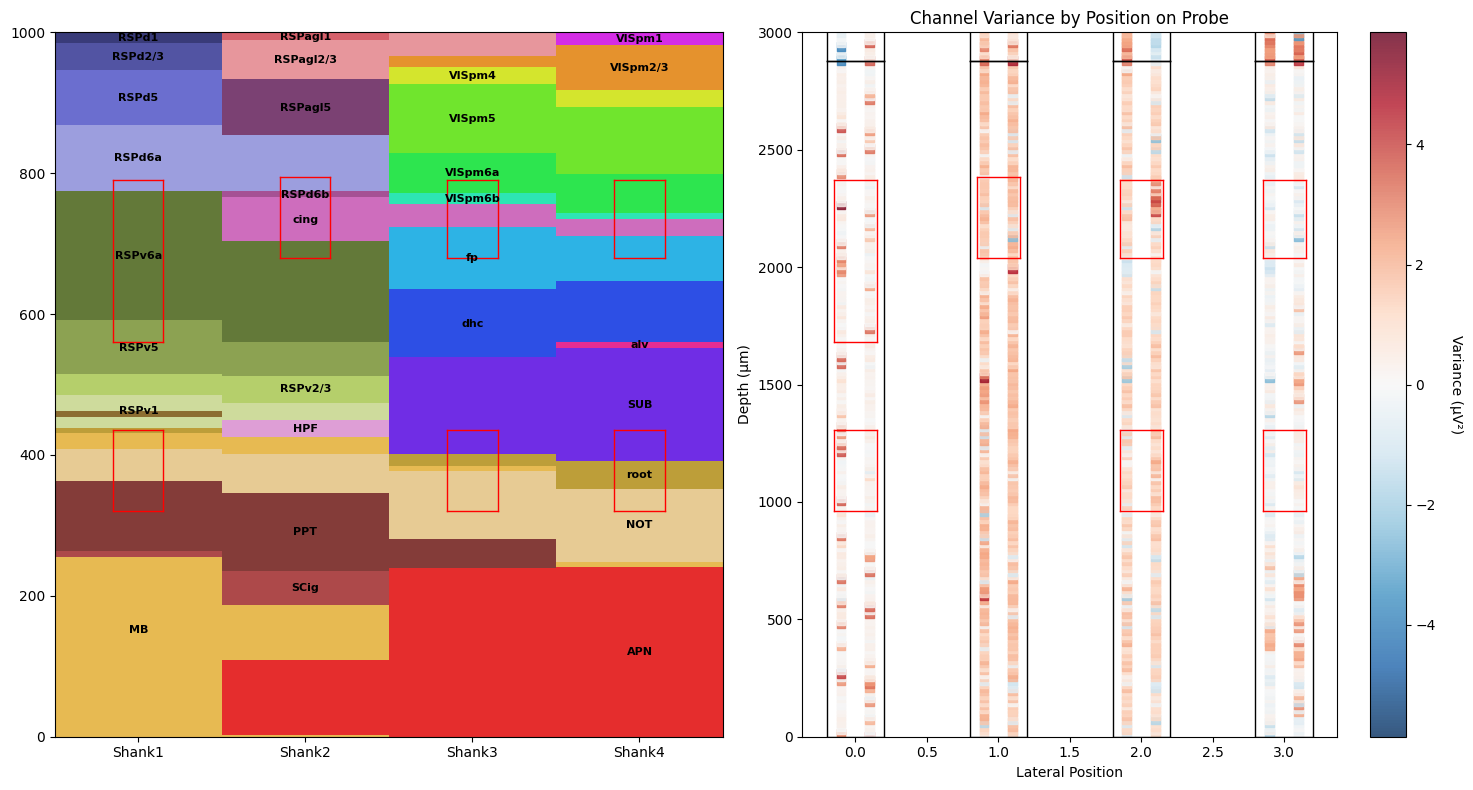

In [353]:
"""Create figure"""

plot = 'means' # 'means' or 'variances'

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

ax = plt.subplot(gs[1])
# Define parameters for visualization
channel_spacing = 15  # µm spacing between channels
n_channels_per_bank = 384/2
bank_vertical_size = channel_spacing * n_channels_per_bank

# Collect all variances for colormap scaling
all_var_values = np.concatenate([bank[plot].flatten() for bank in all_variances])
# Make limits symmetric around zero for diverging colormap
abs_max = max(abs(np.min(all_var_values)), abs(np.max(all_var_values)))
vmin = -abs_max
vmax = abs_max

# For each bank
for bank_data in all_variances:
    bank_id = bank_data['bank']
    variances = bank_data[plot]
    
    # Each bank starts from bottom (lower bank_id) to top
    bank_x_position = bank_data['shank']
    bank_y_start = bank_id * bank_vertical_size
    ax.plot([bank_x_position-0.2, bank_x_position+0.2], [bank_y_start, bank_y_start], color='black', linewidth=1)  # Draw a line for the bank
    ax.plot([bank_x_position-0.2, bank_x_position+0.2], [bank_y_start + bank_vertical_size, bank_y_start + bank_vertical_size], color='black', linewidth=1)  # Draw a line for the bank
    ax.plot([bank_x_position-0.2, bank_x_position-0.2], [bank_y_start, bank_y_start + bank_vertical_size], color='black', linewidth=1)  # Draw a line for the bank
    ax.plot([bank_x_position+0.2, bank_x_position+0.2], [bank_y_start, bank_y_start + bank_vertical_size], color='black', linewidth=1)  # Draw a line for the bank
    
    # Create positions for each channel
    y_positions = np.arange(bank_y_start, bank_y_start + bank_vertical_size, channel_spacing)
    
    # Plot variance values using scatter
    for idx, i in enumerate([-.1,.1]):
        scatter = ax.scatter(
            (np.ones(variances.shape[1])*bank_x_position)+i,  # All channels centered at x=0
            y_positions,               # y positions based on channel index
            c=variances[idx,:],               # color based on variance
            cmap='RdBu_r',            # colormap
            marker='s',                # square markers
            s=40,                      # marker size
            alpha=0.8,                 # transparency
            norm= Normalize(vmin=vmin, vmax=vmax)
        )

# Add colorbar and labels
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Variance (µV²)', rotation=270, labelpad=20)
ax.set_xlabel('Lateral Position')
ax.set_ylim([0,3000])
ax.set_ylabel('Depth (µm)')
ax.set_title('Channel Variance by Position on Probe')
ax.grid(False)

# add the channel map using bank positions
for (bs, bb) in zip(bank_shanks,bank_positions):
    ax.plot([bs-0.15, bs+0.15], [bb[1], bb[1]], color='red', linewidth=1)  # Draw a line for the bank
    ax.plot([bs-0.15, bs+0.15], [bb[0], bb[0]], color='red', linewidth=1)  # Draw a line for the bank
    ax.plot([bs-0.15, bs-0.15], [bb[0], bb[1]], color='red', linewidth=1)  # Draw a line for the bank
    ax.plot([bs+0.15, bs+0.15], [bb[0], bb[1]], color='red', linewidth=1)  # Draw a line for the bank

ylims = ax.get_ylim()

"""add the region map next to it"""
scale = 3
axs = plt.subplot(gs[0])
axs.imshow(region_by_probe.T, aspect='auto', cmap=custom_cmap, norm=norm, interpolation = "none")
axs.set_xticks([0,1,2,3])
axs.set_xticklabels(['Shank1', 'Shank2', 'Shank3', 'Shank4'])

for i, region in enumerate(unique_regions):
    if region == "Not found in brain":
        continue
    x_pos = np.argmax(np.sum(region_by_probe == i, axis=1))
    y_pos = np.mean(np.where(region_by_probe[x_pos,:] == i)[0])
    axs.text(x_pos, y_pos, region, ha='center', va='center', fontsize=8, color='black', weight = 'bold')

# add the channel map using bank positions
for (bs, bb) in zip(bank_shanks,bank_positions):
    axs.plot([bs-0.15, bs+0.15], [bb[1]/scale, bb[1]/scale], color='red', linewidth=1)  # Draw a line for the bank
    axs.plot([bs-0.15, bs+0.15], [bb[0]/scale, bb[0]/scale], color='red', linewidth=1)  # Draw a line for the bank
    axs.plot([bs-0.15, bs-0.15], [bb[0]/scale, bb[1]/scale], color='red', linewidth=1)  # Draw a line for the bank
    axs.plot([bs+0.15, bs+0.15], [bb[0]/scale, bb[1]/scale], color='red', linewidth=1)  # Draw a line for the bank

axs.set_ylim([ylims[0]/scale, ylims[1]/scale])

plt.tight_layout()
plt.show()

In [ ]:
"""Load in the cluster positions"""
# plot all good clusters or only clusters that are sig tuned to %escape